# Getting Started with `vle-thermo` — the High-Level `System` API

This notebook is your first tour of **`vle-thermo`**: install it, build a multicomponent system from component *names*, and run your first vapor–liquid equilibrium flash end-to-end — then scale the same call to 100 000 state points with the batch numpy API.

## Setup (optional)

The cell below is **commented out by default**. Uncomment it to pull the latest `vle-thermo` from PyPI.

In [1]:
# Optional: pull the latest vle-thermo from PyPI.
# Uncomment if you want the newest released version instead of
# whatever is currently in your kernel.
# %pip install --upgrade vle-thermo

## Context from the research paper

From [Chapter I — Introduction](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/chapter-1-introduction.md), this project modernizes a 1999 USB thesis program (Jackson & Mendible) for computing vapor–liquid equilibrium of multicomponent mixtures. The original was a Windows VB6 application driven through dialog boxes; the [Appendix B — User Manual](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/appendices/appendix-b-user-manual.md) walks an analyst through selecting components, an equation of state, and a calculation mode (bubble/dew point, isothermal or adiabatic flash).

> The modern library keeps that mental model — *pick components, pick a > model, pick a calculation* — but exposes it as a Python object you script > instead of a dialog you click. Everything the thesis validated in > [Chapter IV](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/chapter-4-validation.md) is reproducible from a few > lines of Python.

**Units.** The engine is unit-consistent throughout: temperature in **K**, pressure in **kPa absolute** (never gauge), molar enthalpy in **kJ/kmol**, molar entropy in **kJ/(kmol·K)**. Plain numbers you pass are assumed to be in these canonical units; you can also pass unit-aware values (see below).

## What this milestone built

Milestone 10 adds the **ergonomics layer** over the Rust engine:

- **`vle.System`** — a persistent handle that owns the component list and model selection once (no per-call rebuild), with methods `flash_pt`, `flash_ph`, `bubble_pressure`/`_temperature`, `dew_pressure`/`_temperature`, `critical_point`, and `phase_envelope`.
- **`vle.components`** — a bundled JSON database so you build systems from *names* (`"water"`, `"n-butane"`) instead of pasting critical constants.
- **Result dataclasses** (`FlashResult`, `BubbleResult`, …) — named fields in the thesis notation instead of bare tuples.
- **A batch numpy API** (`*_batch`) — array-in/array-out, one FFI crossing per array, GIL released, parallel across cores, warm-started along a sweep.
- **`vle.plots`** — Pxy / Txy / phase-envelope helpers (needs `matplotlib`).

## Worked example — isothermal flash (Chapter IV, Table 4.10)

[Chapter IV §4.6](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/chapter-4-validation.md) validates the isothermal (PT) flash on an **equimolar n-heptane / n-butane** mixture at **300 K** and **100 kPa** using the **RKS** equation of state. The thesis reports a liquid mole fraction $x_1 = 0.6135$, incipient-vapor $y_1 = 0.04284$, and vapor fraction $\beta = 0.19889$. Let's reproduce it.

In [2]:
import vle
from vle import System

print('vle-thermo', vle.__version__)

# Build from names — Tc/Pc/omega/Antoine are pulled from the bundled DB.
sys = System(['n-heptane', 'n-butane'], eos='RKS')
sys

vle-thermo 0.7.0


System(['n-heptane', 'n-butane'])

Now flash it. `flash_pt(T, P, z)` takes temperature (**K**), pressure (**kPa abs**), and the feed composition `z`, and returns a `FlashResult`.

In [3]:
res = sys.flash_pt(300.0, 100.0, z=[0.5, 0.5])
print(f'beta (vapor fraction) = {res.beta:.5f}')
print(f'liquid x = {[round(v, 5) for v in res.x]}')
print(f'vapor  y = {[round(v, 5) for v in res.y]}')
print(f'two-phase = {res.two_phase}, iterations = {res.iterations}')

beta (vapor fraction) = 0.19669
liquid x = [0.61195, 0.38805]
vapor  y = [0.04277, 0.95723]
two-phase = True, iterations = 5


Pin the thesis values so a regression fails loudly (1–5% tolerance):

In [4]:
assert res.two_phase
assert abs(res.x[0] - 0.6135) / 0.6135 < 0.05     # x1
assert abs(res.y[0] - 0.04284) / 0.04284 < 0.05   # y1
assert abs(res.beta - 0.19889) / 0.19889 < 0.05   # beta
print('✓ matches Table 4.10 within tolerance')

✓ matches Table 4.10 within tolerance


### Unit-aware inputs

The same flash, expressed with explicit units. `300 K` is `26.85 °C`, and `100 kPa` can be given as a `"<value> <unit>"` string or a pint quantity. Gauge pressures (`barg`, `psig`) convert automatically.

In [5]:
from vle.units import Q_

res2 = sys.flash_pt(Q_(26.85, 'degC'), '100 kPa', z=[0.5, 0.5])
print(f'beta from unit-aware call = {res2.beta:.5f}  (matches {res.beta:.5f})')
assert abs(res2.beta - res.beta) < 1e-6

beta from unit-aware call = 0.19669  (matches 0.19669)


## Scaling up — the batch API ("numpy for thermo")

A single `flash_pt` crosses the Python↔Rust boundary once. To sweep a whole temperature range you *could* loop in Python, but that pays the boundary cost per point and holds the GIL. `flash_pt_batch` takes numpy arrays, crosses **once per array**, releases the GIL, runs in parallel across cores, and warm-starts each point from its neighbor — roughly a **10× speedup** on this flash. Failed points come back as `NaN` with `converged=False` instead of raising, so one bad state can't kill the sweep.

In [6]:
import numpy as np

ts = np.linspace(285.0, 345.0, 400)      # K
ps = np.array([100.0])                     # kPa — length-1 broadcasts
batch = sys.flash_pt_batch(ts, ps, z=[0.5, 0.5])

print(f'{len(batch)} points, {int(batch.converged.sum())} converged, '
      f'{int(batch.two_phase.sum())} two-phase')

400 points, 400 converged, 351 two-phase


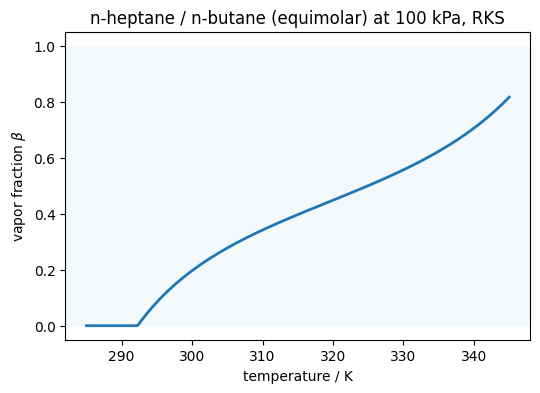

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ts, batch.beta, lw=2)
ax.set_xlabel('temperature / K')
ax.set_ylabel(r'vapor fraction $\beta$')
ax.set_title('n-heptane / n-butane (equimolar) at 100 kPa, RKS')
ax.axhspan(0, 1, alpha=0.05)
plt.show()

The curve climbs from $\beta = 0$ (all liquid, at the bubble temperature) to $\beta = 1$ (all vapor, at the dew temperature) — the two-phase window for this feed at 100 kPa.

### Bubble and dew points directly

You don't have to bracket the flash to find those endpoints — ask for them:

In [8]:
bub = sys.bubble_temperature([0.5, 0.5], 100.0)   # liquid x, fixed P (kPa)
dew = sys.dew_temperature([0.5, 0.5], 100.0)      # vapor y, fixed P (kPa)
print(f'bubble T = {bub.value:.2f} K   dew T = {dew.value:.2f} K')
assert bub.value < dew.value

bubble T = 292.26 K   dew T = 350.58 K


## Exercises

Try these yourself — solutions are collapsed below each one.

### Exercise 1 — a Pxy diagram for a different binary

Build a **benzene / n-hexane** system with the **PR** equation of state and draw its pressure–composition (Pxy) diagram at **350 K** using `vle.plots.pxy_diagram`. Which component is more volatile (higher vapor pressure ⇒ its bubble curve sits at higher P)?

In [9]:
from vle import System
from vle import plots

# TODO: build the benzene/n-hexane system with eos='PR'
# TODO: call plots.pxy_diagram(system, 350.0) and show the figure


<details><summary>Show solution</summary>

```python
import matplotlib.pyplot as plt
bz_hx = System(['benzene', 'n-hexane'], eos='PR')
ax = plots.pxy_diagram(bz_hx, 350.0, n_points=41)
plt.show()
# n-hexane (Pc lower, but higher vapor pressure at 350 K) is the more
# volatile component, so the mixture pressure rises toward pure n-hexane.
```

</details>

### Exercise 2 — bubble pressure across composition, as a batch

For the same **benzene / n-hexane** system at **350 K**, use the **batch** saturation API to compute the bubble pressure for liquid mole fractions `x1 = 0.1, 0.2, …, 0.9` in a single call, and print the array. *Hint:* stack the compositions into an `m × 2` matrix and call `bubble_pressure_batch(xs, ts)` with a length-1 temperature array.

In [10]:
import numpy as np

# TODO: x1 = np.arange(0.1, 0.95, 0.1)
# TODO: xs = np.column_stack([x1, 1 - x1])
# TODO: call bubble_pressure_batch(xs, ts=np.array([350.0])) and print .value


<details><summary>Show solution</summary>

```python
bz_hx = System(['benzene', 'n-hexane'], eos='PR')
x1 = np.arange(0.1, 0.95, 0.1)
xs = np.column_stack([x1, 1 - x1])
res = bz_hx.bubble_pressure_batch(xs, np.array([350.0]))
for xi, p in zip(x1, res.value):
    print(f'x_benzene={xi:.1f}  P_bubble={p:8.2f} kPa')
```

</details>

## References

- [Chapter I — Introduction](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/chapter-1-introduction.md) — project motivation and scope.
- [Appendix B — User Manual](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/appendices/appendix-b-user-manual.md) — the original analyst workflow this API mirrors.
- [Chapter IV — Validation](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/chapter-4-validation.md) — the seven validation cases (Table 4.10 is the flash used above).
- [`PERFORMANCE_PROPOSAL.md`](https://github.com/miguelju/vle/blob/main/docs/plans/engine/PERFORMANCE_PROPOSAL.md) — Track D (the batch numpy API) design and benchmarks.
- Next notebooks: `04_bubble_dew_point`, `05_flash_calculations`, `06_critical_points` reproduce more Chapter IV tables in depth.